## **Importar bibliotecas**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

## **Carregar Dataset**

In [4]:
df = pd.read_csv("ecommerce_kpi_2500.csv")

In [5]:
df

,id_pedido,data,produto,categoria,preco_unitario,quantidade,desconto_rate,receita_bruta,custo_produto,custo_envio,gasto_marketing,margem_bruta,lucro_liquido,roi_marketing,canal_venda,regiao,cliente_id,devolvido
0,741,2024-09-23,Liquidificador,Casa & Cozinha,506.77,1,0.00,506.77,314.19,30.07,1.06,192.58,161.45,153.311,WhatsApp,Nordeste,10328,0
1,1661,2024-09-23,Halteres 5kg,Esportes,931.28,4,0.00,3725.12,2421.32,18.69,7.53,1303.80,1277.58,170.665,Site,Sudeste,10228,0
2,209,2024-09-23,Hidratante,Beleza,190.19,2,0.07,353.75,190.20,9.06,8.50,163.55,145.99,18.176,Site,Sudeste,10675,0
3,124,2024-09-23,Maquiagem,Beleza,400.00,1,0.11,356.00,200.00,18.86,16.73,156.00,120.41,8.197,Marketplace,Sul,10888,0
4,255,2024-09-23,Maquiagem,Beleza,67.49,1,0.07,62.77,33.74,38.30,9.20,29.03,-18.47,-1.008,Marketplace,Nordeste,11099,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,571,2025-09-22,Calça Jeans,Moda,458.86,2,0.00,917.72,504.74,27.24,1.42,412.98,384.32,271.648,Site,Norte,11091,0
2496,2494,2025-09-22,Tênis Running,Moda,314.34,2,0.00,628.68,345.78,15.46,11.14,282.90,256.30,24.007,Marketplace,Sudeste,10847,0
2497,2115,2025-09-22,Perfume,Beleza,305.17,4,0.00,1220.68,610.32,14.14,14.74,610.36,581.48,40.449,Marketplace,Sul,10865,0
2498,2402,2025-09-22,Tênis Running,Moda,246.80,1,0.00,246.80,135.74,21.91,2.86,111.06,86.29,31.171,WhatsApp,Sudeste,10580,0


## **Proporções do Dataset**

In [6]:
df.shape

(2500, 18)

## **Verificação de dados faltantes**

In [7]:
df.isnull().sum()

id_pedido           0
data                0
produto             0
categoria           0
preco_unitario      0
quantidade          0
desconto_rate       0
receita_bruta       0
custo_produto       0
custo_envio         0
gasto_marketing     0
margem_bruta        0
lucro_liquido       0
roi_marketing      49
canal_venda         0
regiao              0
cliente_id          0
devolvido           0
dtype: int64

O dataset possui 49 dados faltantes em apenas uma coluna.

## **Tratamento de dados referente a coluna com dados nulos**

In [8]:
df['roi_marketing'].fillna(df['roi_marketing'].mean(), inplace=True)

C:\Users\Unkno\AppData\Local\Temp\ipykernel_13036\2202040850.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['roi_marketing'].fillna(df['roi_marketing'].mean(), inplace=True)


In [9]:
df.isnull().sum()

id_pedido          0
data               0
produto            0
categoria          0
preco_unitario     0
quantidade         0
desconto_rate      0
receita_bruta      0
custo_produto      0
custo_envio        0
gasto_marketing    0
margem_bruta       0
lucro_liquido      0
roi_marketing      0
canal_venda        0
regiao             0
cliente_id         0
devolvido          0
dtype: int64

Foi utilizado o valor da média para preencher os valores nulos.

In [10]:
df['roi_marketing'].mean()

np.float64(69.67457201142392)

## **Top 5 produtos mais vendidos**

In [11]:
top_5_prod = df.groupby('produto')['receita_bruta'].sum().sort_values(ascending=False).head(5)

In [12]:
top_5_prod

produto
Smartphone          263547.15
TV 50"              255504.05
Teclado Mecânico    207284.57
Fone Bluetooth      206651.32
Mouse Gamer         199125.71
Name: receita_bruta, dtype: float64

In [13]:
(top_5_prod/df['receita_bruta'].sum() * 100).sum()

np.float64(35.45530046160864)

Os 5 produtos mais vendidos representam 35.4% da receita total.

## **Top 5 produtos com maior custo de produção**

In [14]:
top_5_cost = df.groupby('produto')['custo_produto'].sum().sort_values(ascending=False).head()

In [15]:
margem_5 = ((top_5_prod - top_5_cost) / top_5_prod) * 100

In [16]:
margem_5

produto
Smartphone          27.010248
TV 50"              25.671777
Teclado Mecânico    25.923748
Fone Bluetooth      25.914686
Mouse Gamer         25.356334
dtype: float64

## **Receita e Lucro por Categoria**

In [17]:
receita_cat = df.groupby('categoria')[['receita_bruta', 'lucro_liquido']].sum().sort_values('receita_bruta', ascending=False)

In [18]:
receita_cat

,receita_bruta,lucro_liquido
categoria,,
Eletrônicos,1329762.74,332809.50
Esportes,806679.73,257674.38
Casa & Cozinha,418663.84,140400.54
Brinquedos,265098.69,95736.35
Moda,229692.81,85985.80
Beleza,143172.86,58069.86


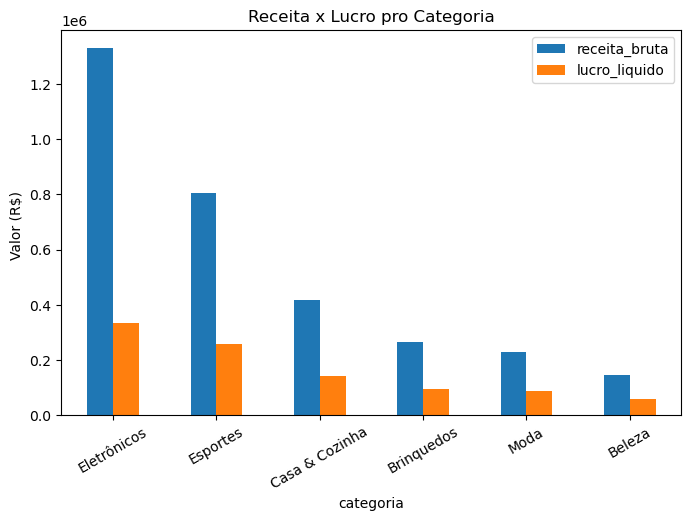

In [19]:
receita_cat.plot(kind="bar", figsize=(8, 5))
plt.title('Receita x Lucro pro Categoria')
plt.ylabel('Valor (R$) ')
plt.xticks(rotation=30)
plt.show()

## **Ticket Médio por Canal de Venda**

In [20]:
ticket_canal = df.groupby('canal_venda')['receita_bruta'].mean().sort_values(ascending=False)

In [21]:
ticket_canal

canal_venda
Marketplace    1334.050213
WhatsApp       1330.772512
Site           1322.335521
TikTok Shop    1215.485618
Instagram      1025.306957
Name: receita_bruta, dtype: float64

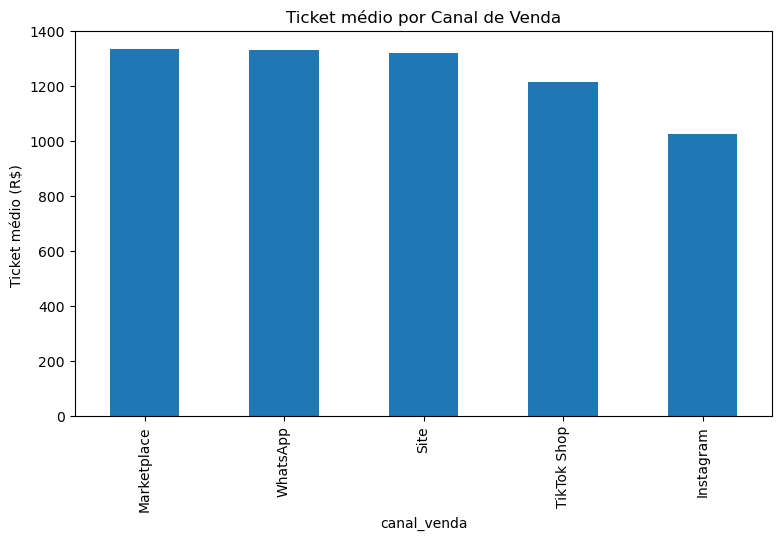

In [22]:
ticket_canal.plot(kind='bar', figsize=(9, 5))
plt.title('Ticket médio por Canal de Venda')
plt.ylabel('Ticket médio (R$) ')
plt.show()

## **Taxa de Devolução por Categoria**

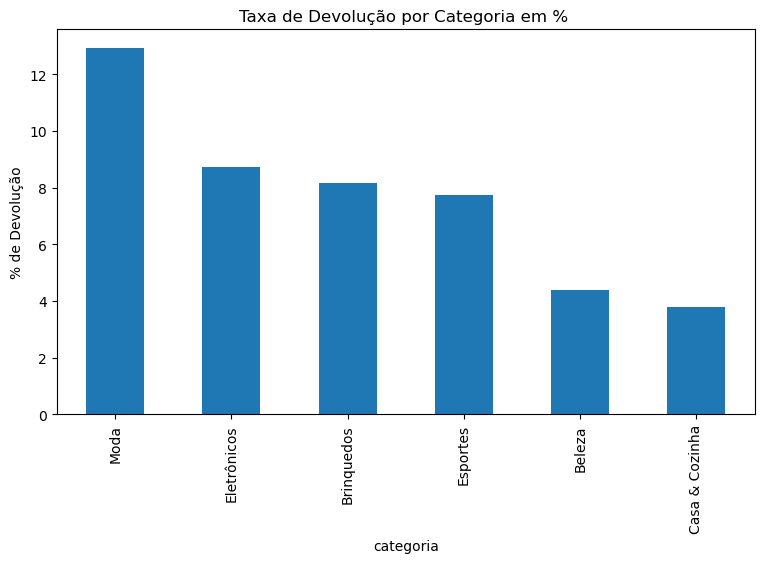

In [24]:
dev_p_cat = df.groupby('categoria')['devolvido'].mean().sort_values(ascending=False)*100
dev_p_cat.plot(kind='bar', figsize = (9,5))
plt.title('Taxa de Devolução por Categoria em % ')
plt.ylabel('% de Devolução')
plt.show()

## **ROI de Marketing por Canal**

In [26]:
roi_can = df.groupby('canal_venda')['roi_marketing'].mean().sort_values(ascending=False)

In [28]:
roi_can

canal_venda
WhatsApp       177.429665
Site            83.041144
TikTok Shop     53.750709
Marketplace     40.164813
Instagram       22.681152
Name: roi_marketing, dtype: float64

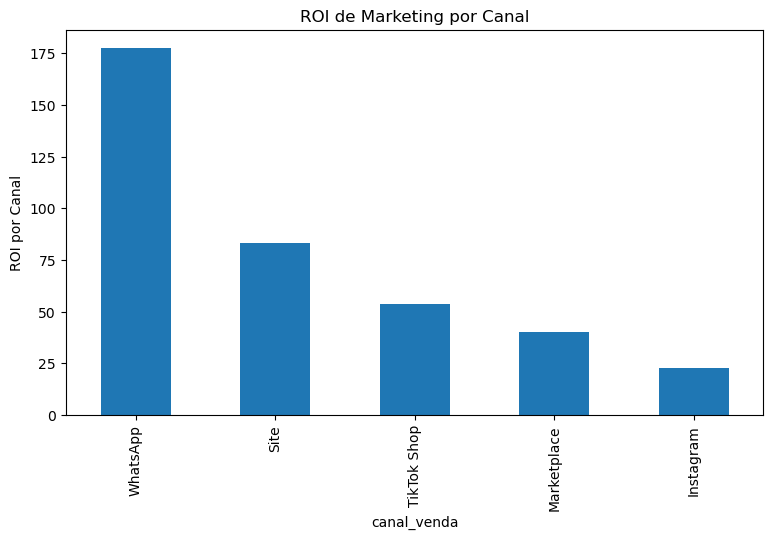

In [29]:
roi_can.plot(kind='bar', figsize = (9,5))
plt.title('ROI de Marketing por Canal')
plt.ylabel('ROI por Canal')
plt.show()

O WhatsApp isolado possui equivalência dos seguintes canais: Site, TikTok Shop e Marketplace.


## **Receita Mensal (Tendência)**

In [30]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')

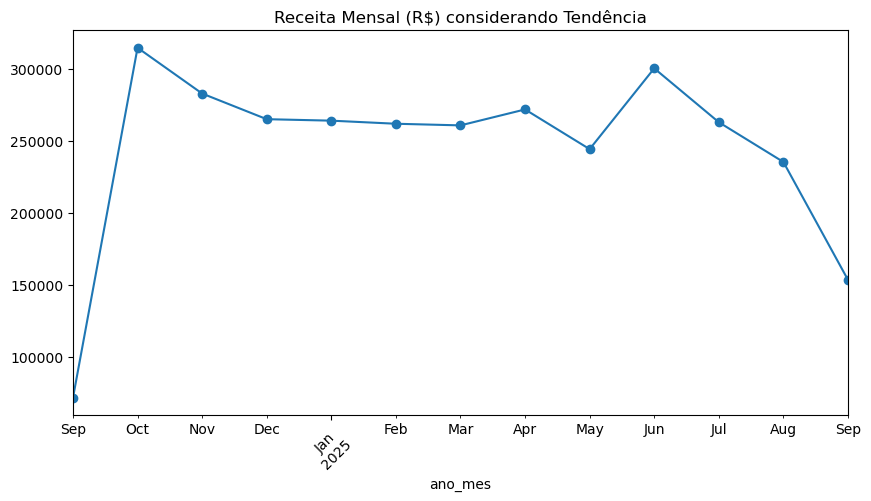

In [31]:
df['ano_mes'] = df['data'].dt.to_period('M')
receita_mensal = df.groupby('ano_mes')['receita_bruta'].sum()

receita_mensal.plot(marker='o', figsize = (10,5))
plt.title('Receita Mensal (R$) considerando Tendência')
plt.ylabel('')
plt.xticks(rotation=45)
plt.show()

## **Clientes Frequentes (Top Compradores)**

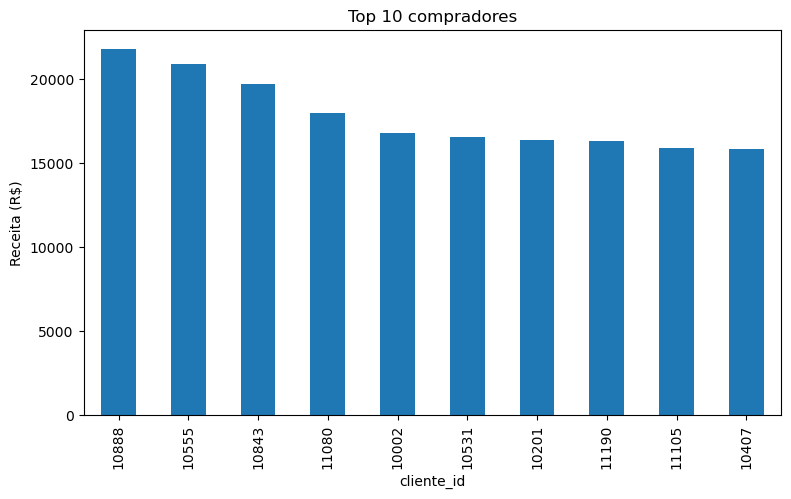

In [32]:
top_10_comp = df.groupby('cliente_id')['receita_bruta'].sum().sort_values(ascending=False).head(10)
top_10_comp.plot(kind='bar', figsize = (9,5))
plt.title('Top 10 compradores')
plt.ylabel('Receita (R$)')
plt.show()

# **Margem Bruta por Categoria**

C:\Users\Unkno\AppData\Local\Temp\ipykernel_13036\4151778565.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  margem_cat = df.groupby('categoria').apply(


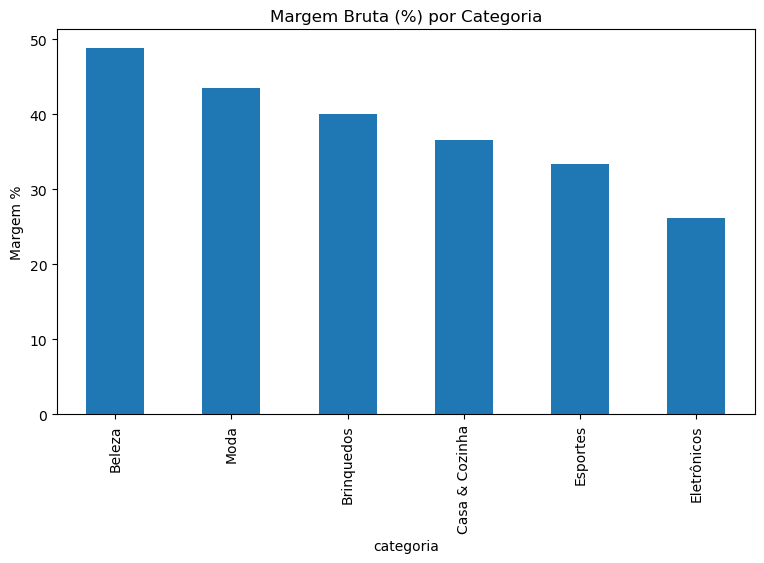

In [35]:
margem_cat = df.groupby('categoria').apply(
    lambda x: x['margem_bruta'].sum() / x['receita_bruta'].sum() * 100
).sort_values(ascending=False)

margem_cat.plot(kind='bar', figsize = (9,5))
plt.title('Margem Bruta (%) por Categoria')
plt.ylabel('Margem %')
plt.show()

## **Insights**

Receita e Lucro por Categoria → Eletrônicos lideram em receita, mas beleza e moda podem gerar margens mais altas.

Ticket Médio por Canal → Marketplace costuma ter ticket médio maior, enquanto redes sociais atraem compras menores.

Taxa de Devolução → Moda e Eletrônicos concentram mais devoluções → sinal de problemas em tamanho/qualidade.

ROI de Marketing → WhatsApp tende a ser mais eficiente; Instagram pode apresentar ROI negativo.

Receita Mensal → Possíveis quedas nos últimos meses e picos em sazonalidades (ex.: Black Friday).

Clientes Frequentes → Poucos clientes podem concentrar grande parte da receita → importante fidelizar.

Margem Bruta por Categoria → Beleza tem margens altas (ótima para promoções); Eletrônicos precisam de volume para compensar margens baixas.